# **Proyecto Sprint 6**

## Objetivo Principal
Analizar los datos históricos de ventas y reseñas de videojuegos hasta 2016 para identificar patrones de éxito que permitan predecir cuáles serán los productos más rentables en 2017. El fin es diseñar una estrategia comercial inteligente adaptada a las preferencias de cada región (Norteamérica, Europa y Japón).

##  Plan de acción:


1. Lectura y análisis de estructura inicial
Lo primero es cargar nuestra herramienta principal (Pandas) y echarle un vistazo rápido a lo que tenemos entre manos para entender con qué estamos trabajando:

      - Dimensiones: Ver qué tan grande es el dataset (filas y columnas).

      - Limpieza de nombres: Revisar que los títulos de las columnas no tengan espacios raros, mayúsculas estorbosas o errores que nos den problemas después al escribir código.

      - Tipos de información: Confirmar si los números se están leyendo como números y los textos como textos.

      - Detectar huecos: Identificar dónde nos faltan datos (valores ausentes) y si hay filas repetidas que puedan ensuciar nuestros resultados.

2. Preparación de los datos (Poner todo en orden)
Una vez que sabemos qué está mal, pasamos a "arreglar la casa" para que el análisis sea fluido:

      - Corrección de formatos: Ajustar los nombres de las columnas a un formato estándar (todo en minúsculas y con guiones bajos) y convertir datos que parezcan números pero que el sistema lea como texto (como el caso de los puntajes).

      - Tratamiento de ausentes: Decidir qué hacer con los espacios vacíos. No se trata solo de borrarlos, sino de pensar si podemos llenarlos con lógica o si es mejor dejarlos como están para no inventar información.

      - Nuevos cálculos: Crear una columna de Ventas Totales sumando todas las regiones, para tener una métrica global de éxito de cada juego.

3. Análisis exploratorio (Buscando historias en los datos)
Aquí es donde empezamos a buscar patrones sin entrar todavía en comparaciones complejas:

      - Ver cuántos juegos se lanzaban por año y detectar cuándo hubo "épocas doradas".

      - Identificar qué consolas (plataformas) han vendido más y cuánto tiempo suelen durar siendo populares antes de que la gente las olvide.

      - Ver si las notas de los críticos realmente ayudan a que un juego venda más o si el público compra por otras razones.

4. Perfil regional (¿Quién compra qué?)
Dividiremos el mundo para entender a los clientes de cada zona:

      - Comparar qué se juega en Norteamérica, Europa y Japón.

      - Analizar si las clasificaciones de edad (como la ESRB) afectan las ventas de forma distinta dependiendo de la cultura de cada región.

5. Prueba de hipótesis (Validación científica)
Para terminar, no nos quedaremos solo con lo que "parece" cierto, sino que usaremos estadística para confirmarlo:

      - Xbox One vs PC: Comprobaremos si los usuarios de ambas plataformas realmente califican los juegos de la misma manera o si hay una diferencia real.

      - Acción vs Deportes: Analizaremos si el nivel de satisfacción de los jugadores cambia según el tipo de juego que prefieren.

      - Uso de P-value: Utilizaremos herramientas matemáticas para estar seguros de que nuestras conclusiones no son por pura coincidencia o azar

# 1. Lectura y analisis de estructura inicial:

### 1.1 Carga de funcionalidades y recursos.

Usaremos las Funciones primarias al empezar a analizar un Datafram.

- Cargamos la Libreria "Pandas para poder iterar sobre el Dataframe par ayudarnos a modificar, filtrar y corregir los posibles errores y extraer la información mas adelante.
- Carga del Dataset en Formato "csv" para la iteracion sobre el.
- Analisis de tipos de valores, estructura, tamaño, valores ausentes y duplicados.

In [ ]:
# Importamos de inicio la libreria pandas para trabajar con el archivo .csv y poderlo manipular.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

df_games = pd.read_csv('/content/drive/MyDrive/bootcamp triple10/games.csv')

In [ ]:
print("1. Mostramos la Informacion de las columnas, tamaño, y tipos de valores almacenados dentro del dataframe:")
print()
df_games.info()
print("=="*150)
print()
print("2. Se imprime una muestra de dataframe y su estructura inicial:")
print()
display(df_games.sample(5,random_state=15))
print("=="*150)
print("3. El numero total de valores ausentes es de:")
print()
print(df_games.isna().sum())
print()
print(f"3.1 Total de valores asuentes:{(df_games.isna().sum()).sum()}")
print()
print("=="*150)
print("4. Mostramos los nombres de las columnas para verificar si sus estructura es correcta.")
print()
print(df_games.columns)
print("=="*150)
print("5. Numero de Filas Duplicadas:")
print()
print(df_games.duplicated().value_counts())



1. Mostramos la Informacion de las columnas, tamaño, y tipos de valores almacenados dentro del dataframe:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB

2. Se imprime una muestra de dataframe y su estructura inicial:



,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
12288,Kabuki Warriors,XB,2001.0,Action,0.05,0.01,0.00,0.00,32.0,2.5,M
4073,Shrek the Third,PS2,2007.0,Action,0.40,0.02,0.00,0.07,56.0,6.1,E10+
2365,Star Wars: Rebel Assault II - The Hidden Empire,PS,1996.0,Shooter,0.49,0.33,0.00,0.06,NaN,NaN,NaN
3363,LEGO The Hobbit,PS4,2014.0,Action,0.13,0.38,0.00,0.09,72.0,6.6,E10+
1075,Saints Row 2,PS3,2008.0,Action,0.88,0.54,0.02,0.25,82.0,7.9,M


3. El numero total de valores ausentes es de:

Name                  2
Platform              0
Year_of_Release     269
Genre                 2
NA_sales              0
EU_sales              0
JP_sales              0
Other_sales           0
Critic_Score       8578
User_Score         6701
Rating             6766
dtype: int64

3.1 Total de valores asuentes:22318

4. Mostramos los nombres de las columnas para verificar si sus estructura es correcta.

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'NA_sales', 'EU_sales',
       'JP_sales', 'Other_sales', 'Critic_Score', 'User_Score', 'Rating'],
      dtype='object')
5. Numero de Filas Duplicadas:

False    16715
Name: count, dtype: int64


## 1.2 Observaciones iniciales:

El Dataframe tiene una estructura de 11 columnas (6 tipo: **`float`**, 5 tipo: **`object`**), 16715 filas,

Como primera observación notamos los siguientes detalles en las columnas y sus valores:
- Nombres de las Columnas aunque tienen estructura **`snake_case`** estan escritos con su primer letra en mayuscula y esto puede complicar el filtrado. **(Se corregira usando `games_df.columns = games_df.columns.str.lower().`)** para convertir los nombres en minúsculas.
- Tenemos valores ausentes en las columnas: **`['Name', 'Year_of_Release', 'Genre', 'Critic_Score', 'User_Score', 'Rating']`**, par un total de **`22318`** valores ausentes entre todas estas columnas. Se examinaran mas a detalle las columnas para detectar si siguen un patron estos valores ausentes y se aislaran en una variable por separado.
- La columna **`year_of_release`** esta en formato **`float`** cuando deberia ser **`int`**. **(Se corregira usando: `df_games['year_of_release'].astype('int')`)**
- Alparecer no tenemos de inicio, filas duplicadas dentro del Dataframe.

# 2. Preparacion de los datos

### 2.1 Correccion de Valores Erroneos y Faltantes.

In [ ]:
# Usamos el metodo ".lower()" sobre "columns" del df despeus de verificar que es el unico problema notable con los nombres de las columnas.

df_games.columns = df_games.columns.str.lower()

display(df_games.head(2))

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN


**Usamos el metodo ".lower()" sobre "columns" del df despues de verificar que es el único problema notable con los nombres de las columnas.**

In [ ]:
no_release_year = df_games[df_games['year_of_release'].isna()]
no_name = df_games[df_games['name'].isna()]
print(no_release_year['name'].value_counts())
print("=="*150)
print(no_name)
print()
print(f"El numero de valores nulos en 'year_of_release' es: {len(no_release_year)}")
print("=="*150)
print()
print(f"El numero de valores nulos en 'name' es: {len(no_name)}")

name
LEGO Harry Potter: Years 5-7         7
Rock Band                            4
Happy Feet Two                       4
Test Drive Unlimited 2               3
WRC: FIA World Rally Championship    3
                                    ..
Brothers in Arms: Furious 4          1
Agarest Senki: Re-appearance         1
Freaky Flyers                        1
Inversion                            1
Hakuouki: Shinsengumi Kitan          1
Name: count, Length: 232, dtype: int64
      name platform  year_of_release genre  na_sales  eu_sales  jp_sales  \
659    NaN      GEN           1993.0   NaN      1.78      0.53      0.00   
14244  NaN      GEN           1993.0   NaN      0.00      0.00      0.03   

       other_sales  critic_score user_score rating  
659           0.08           NaN        NaN    NaN  
14244         0.00           NaN        NaN    NaN  

El numero de valores nulos en 'year_of_release' es: 269

El numero de valores nulos en 'name' es: 2


In [ ]:
porcentaje_sin_salida = (len(no_release_year)/len(df_games))
print ()

**Investigamos los valores ausentes en la columna "name" y "year_of_release", y se almacenaron en variables independientes.**

- Dado que el establecer fechas inventadas podria crecer artificialmente los siguientes analisis decidimos lo siguiente.:

- Se identificó un 1.61% de valores ausentes en la columna year_of_release. Dado que es un porcentaje bajo, determinamos que no representan un valor significativo que pueda sesgar los datos para el analisis posterior que realizaremos por lo que eliminaremos todas las columnas con año de lanzamiento nulos.

- Los campos sin nombre al ser solo 2 se eliminara igualmente no representan un valor significativo y no podemos saber a que juego se refieren.

- Ademas al final Convertiremos la columna de 'year_of_release' de tipo float a tipo 'int'.


In [ ]:
from IPython.utils.sysinfo import pprint
df_games = df_games.dropna(subset=['year_of_release'])
df_games = df_games.dropna(subset=['name'])

print(df_games.isna().sum())
print("=="*150)
df_games['year_of_release'] = df_games['year_of_release'].astype('int')

print(df_games.info())
print("=="*150)
display(df_games.sample(5,random_state=15))

name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8461
user_score         6605
rating             6676
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 16444 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  int64  
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       9839 non-null   object 
 10  rating           9768 non-null   object 
dtypes: float64(5), i

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
11089,Space Chimps,Wii,2008,Platform,0.08,0.00,0.00,0.01,NaN,tbd,E10+
9905,Alice: Madness Returns,PC,2011,Adventure,0.00,0.10,0.00,0.02,75.0,8.4,M
2053,Prince of Persia,X360,2008,Action,0.54,0.34,0.02,0.10,81.0,7,T
9244,Daytona USA Championship Circuit Edition,SAT,1995,Racing,0.00,0.00,0.14,0.00,NaN,NaN,NaN
6881,4x4 EVO 2,XB,2001,Racing,0.18,0.05,0.00,0.01,59.0,6.2,E


Investigamos los Valores unicos en la Columna "critic_score", "user_score" y "rating"

Despues de Analizar los Valores unicos dentro de las columnas 'critic_score', 'user_score', 'rating', concluimos en que debemos hacer lo siguiente:

- Conservar los Valores nulos como estan en las columnas "['critic_score', 'user_score], ya que eliminarlos, estariamos eliminando datos de ventas que tambien estariamos ocupando posteriormente.
- Los valores Nulos en estas columnas no significan ausencia de datos si no que talvez los juegos en ellas no tienen suficientes reseñas como para poder establecer una calificación propiamente.
- Tambien notamos que los juegos sin reseñas tiene un bajo indice de ventas que podria ser el indicativo a por que no tienen reseñas que permitan otorgarle una calificación.
- Se transformó la columna "user_score" a tipo "float" y Los valores "TBD" se trataron como nulos (NaN) para evitar sesgos en el análisis estadístico, ya que representan información inexistente al momento de la extracción.
- Especificamente la columna de ["rating"] se relleno con "Unknown", ya que en realidad no sabemos si no cuenta con un sistema de clasificación ya que puede que cada region maneje su propio sistema de clasificación.

In [ ]:
for col in ['critic_score', 'user_score', 'rating']:
    print(f"Valores únicos en {col}:", df_games[col].unique())

Valores únicos en critic_score: [76. nan 82. 80. 89. 58. 87. 91. 61. 97. 95. 77. 88. 83. 94. 93. 85. 86.
 98. 96. 90. 84. 73. 74. 78. 92. 71. 72. 68. 62. 49. 67. 81. 66. 56. 79.
 70. 59. 64. 75. 60. 63. 69. 50. 25. 42. 44. 55. 48. 57. 29. 47. 65. 54.
 20. 53. 37. 38. 33. 52. 30. 32. 43. 45. 51. 40. 46. 39. 34. 41. 36. 31.
 27. 35. 26. 19. 28. 23. 24. 21. 17. 13.]
Valores únicos en user_score: ['8' nan '8.3' '8.5' '6.6' '8.4' '8.6' '7.7' '6.3' '7.4' '8.2' '9' '7.9'
 '8.1' '8.7' '7.1' '3.4' '5.3' '4.8' '3.2' '8.9' '6.4' '7.8' '7.5' '2.6'
 '7.2' '9.2' '7' '7.3' '4.3' '7.6' '5.7' '5' '9.1' '6.5' 'tbd' '8.8' '6.9'
 '9.4' '6.8' '6.1' '6.7' '5.4' '4' '4.9' '4.5' '9.3' '6.2' '4.2' '6' '3.7'
 '4.1' '5.8' '5.6' '5.5' '4.4' '4.6' '5.9' '3.9' '3.1' '2.9' '5.2' '3.3'
 '4.7' '5.1' '3.5' '2.5' '1.9' '3' '2.7' '2.2' '2' '9.5' '2.1' '3.6' '2.8'
 '1.8' '3.8' '0' '1.6' '9.6' '2.4' '1.7' '1.1' '0.3' '1.5' '0.7' '1.2'
 '2.3' '0.5' '1.3' '0.2' '0.6' '1.4' '0.9' '1' '9.7']
Valores únicos en rating: ['E' nan 

In [ ]:
no_reviews = df_games[['critic_score', 'user_score', 'rating']].isna().any(axis=1)

no_games_reviews = df_games[no_reviews]

display(no_games_reviews.sample(10))

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
12419,LEGO Bionicle,GBA,2001,Platform,0.04,0.02,0.00,0.00,NaN,tbd,E
5237,Ganbare Goemon 3: Shishi Jyuurokubei no Karaku...,SNES,1994,Platform,0.00,0.00,0.36,0.00,NaN,NaN,NaN
8419,I'm A Celebrity: Get Me Out of Here!,Wii,2009,Misc,0.00,0.16,0.00,0.01,NaN,NaN,NaN
13878,Sonic PC Collection,PC,2009,Misc,0.00,0.04,0.00,0.00,NaN,NaN,NaN
3992,Super Famista 5,SNES,1996,Sports,0.00,0.00,0.50,0.00,NaN,NaN,NaN
10632,Indy Racing 2000,N64,2000,Racing,0.08,0.02,0.00,0.00,NaN,NaN,NaN
14301,Let's Sing 2016,PS4,2015,Action,0.03,0.00,0.00,0.01,NaN,tbd,T
7487,J-League Pro Soccer Club o Tsukurou! 7 Euro Plus,PSP,2011,Sports,0.00,0.00,0.21,0.00,NaN,NaN,NaN
10117,Happy Feet Two,3DS,2011,Action,0.08,0.02,0.00,0.01,NaN,NaN,NaN
1278,Wario Land II,GB,1997,Platform,0.70,0.35,0.39,0.04,NaN,NaN,NaN


In [ ]:
df_games['user_score'] = pd.to_numeric(df_games['user_score'], errors='coerce')

In [ ]:
df_games['rating'] = df_games['rating'].fillna('Unknown')

In [ ]:
print(df_games.info())
print("=="*100)
print(df_games.isna().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 16444 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  int64  
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       7463 non-null   float64
 10  rating           16444 non-null  object 
dtypes: float64(6), int64(1), object(4)
memory usage: 1.5+ MB
None
name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8461
user_score     

**Con este paso verificamos que los pasos anteriores, se realizaron con exito:**

- Nombres de columnas en formato snake_case y en minusculas.
- Columna "year_of_release" en formato "int".
- Columnas "critic_score" y "user_score" en formato "float".
- Valores nulos eliminados de todas las columnas excepto de "critic_score" y "user_score.


### 2.2 Eriquecimiento de Datos

En este paso crearemos una columna nueva dentro del DataFrame en la cual estariamos colocando la suma del total de todas las ventas por region en un solo resultado que nos servira para comparar las ventas en relacion a cada region o que porcentaje del total representa cada region.

In [ ]:
sales_columns = ['na_sales',	'eu_sales',	'jp_sales',	'other_sales']

df_games['total_sales'] = df_games[sales_columns].sum(axis=1)

display(df_games.sample(5,random_state=15))

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
11089,Space Chimps,Wii,2008,Platform,0.08,0.00,0.00,0.01,NaN,NaN,E10+,0.09
9905,Alice: Madness Returns,PC,2011,Adventure,0.00,0.10,0.00,0.02,75.0,8.4,M,0.12
2053,Prince of Persia,X360,2008,Action,0.54,0.34,0.02,0.10,81.0,7.0,T,1.00
9244,Daytona USA Championship Circuit Edition,SAT,1995,Racing,0.00,0.00,0.14,0.00,NaN,NaN,Unknown,0.14
6881,4x4 EVO 2,XB,2001,Racing,0.18,0.05,0.00,0.01,59.0,6.2,E,0.24


# 3. Analisis de los Datos

### 3.1 Juegos lanzados por año.

Agruparemos los juegos por su año de lanzamiento para determinar si existen periodos significativos para el análisis.

Para efectos de visualización de los datos, importaremos la librería matplotlib.

Crearemos un gráfico de barras utilizando el conteo de los nombres de los juegos en el eje Y y los años en el eje X.

In [ ]:
import matplotlib.pyplot as plt

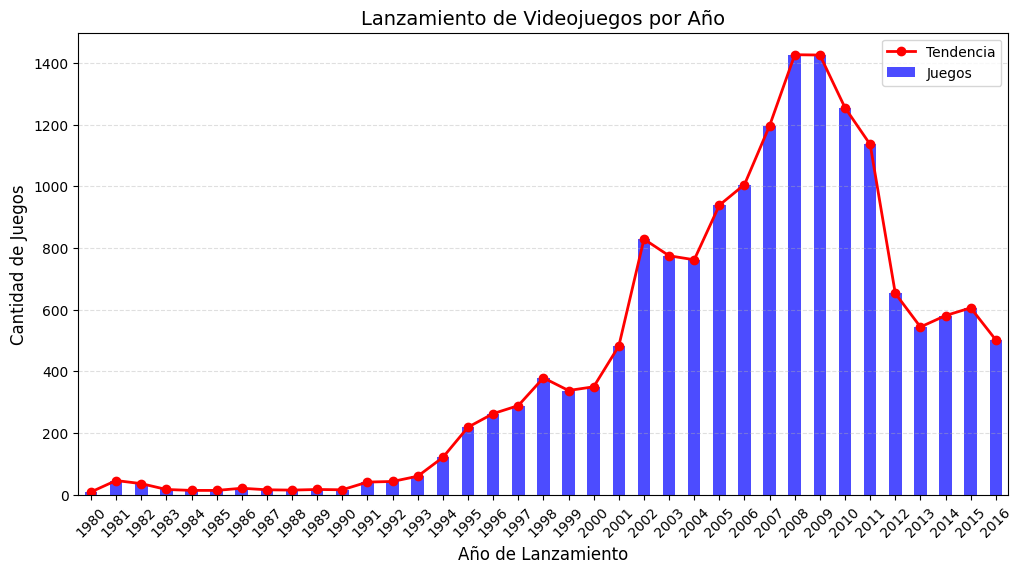

In [ ]:
games_per_year = df_games.groupby('year_of_release')['name'].count()

ax = games_per_year.plot(kind='bar', figsize=(12, 6), color='blue', alpha=0.7, label='Juegos')

plt.plot(range(len(games_per_year)), games_per_year.values, color='red', marker='o', linewidth=2, label='Tendencia')

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.title('Lanzamiento de Videojuegos por Año', fontsize=14)
plt.xlabel('Año de Lanzamiento', fontsize=12)
plt.ylabel('Cantidad de Juegos', fontsize=12)
plt.legend(["Juegos"])
plt.xticks(rotation=45)
plt.legend()

plt.show()

**Obvservaciones:**

- Entre 1980 y 1994, la tendencia de los datos es relativamente plana, lo que indica que no hubo un crecimiento significativo en la industria durante este periodo.

- De 1994 a 2002, observamos un incremento notable, impulsado por la introducción de nuevas tecnologías en las consolas, como la implementación de discos CD.

- El punto máximo se alcanzó entre 2008 y 2009, periodo en el cual la industria superó los 1400 lanzamientos anuales.

- A partir de 2009 y hasta 2016, la cantidad de lanzamientos ha disminuido, con una caída drástica desde 2011. Esto puede atribuirse a que, a partir de cierto año, los títulos comenzaron a consolidarse como proyectos de mayor envergadura (juegos AAA); si bien esto redujo el volumen total, permitió un enfoque superior en la calidad y la adaptación a nuevas tecnologías.

### 3.2 Ventas por Plataforma

- Iniciaremos agrupando las ventas totales por plataforma para identificar el top 5 con mayor volumen de ventas.

- Crearemos un gráfico de estas cinco plataformas para visualizar sus respectivos ciclos de vida.

- Filtraremos el dataframe para descartar aquellas plataformas que no presentan ventas recientes.

In [ ]:
platform_sales = df_games.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
display(platform_sales.head(10))

,total_sales
platform,
PS2,1233.56
X360,961.24
PS3,931.34
Wii,891.18
DS,802.78
PS,727.58
PS4,314.14
GBA,312.88
PSP,289.53


Tras identificar las 10 principales plataformas, procederemos a generar nuestros gráficos enfocándonos únicamente en el top 5 (PS2, X360, PS3, Wii y DS).

Para ello, almacenaremos los datos correspondientes a estas cinco plataformas en una variable dedicada para facilitar su manipulación.

In [ ]:
top_platforms = df_games.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head(5)

list_top_5 = top_platforms.index

<Figure size 1000x600 with 0 Axes>

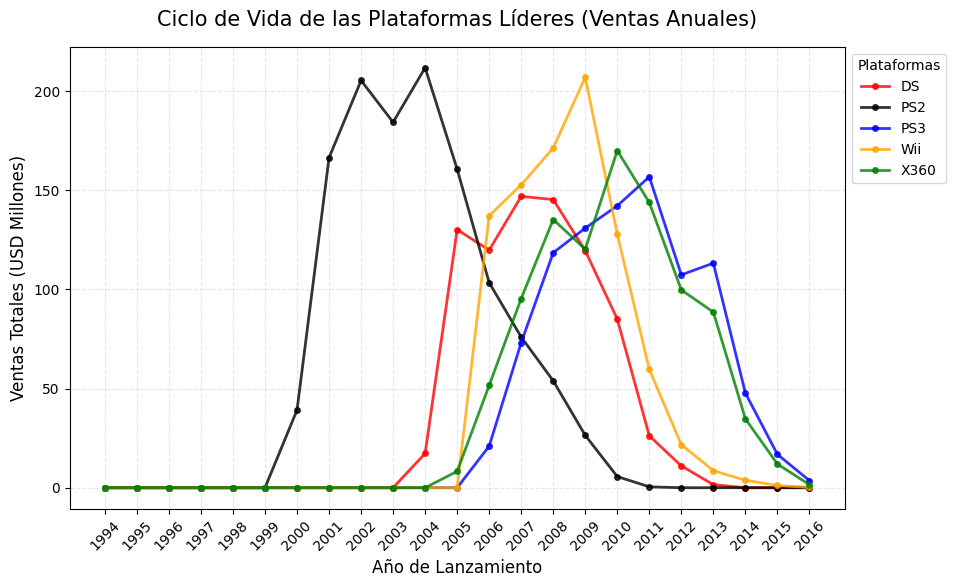

In [ ]:
top_platforms_names = df_games.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head(5).index

df_top_5 = df_games[df_games['platform'].isin(top_platforms_names)]

pivot_top_5 = df_top_5.pivot_table(index='year_of_release',
                                   columns='platform',
                                   values='total_sales',
                                   aggfunc='sum')

all_years = range(int(pivot_top_5.index.min()), int(pivot_top_5.index.max()) + 1)

pivot_top_5 = pivot_top_5.reindex(all_years).fillna(0)

pivot_top_5 = pivot_top_5.query('index >= 1994')

plt.figure(figsize=(10, 6))

ax = pivot_top_5.plot(
    kind='line',
    figsize=(10, 6),
    marker='o',
    markersize=4,
    linewidth=2,
    alpha=0.8,
    color=('red', 'black', 'blue', 'orange', 'green')
    )

plt.title('Ciclo de Vida de las Plataformas Líderes (Ventas Anuales)', fontsize=15, pad=15)
plt.xlabel('Año de Lanzamiento', fontsize=12)
plt.ylabel('Ventas Totales (USD Millones)', fontsize=12)
plt.xticks(pivot_top_5.index, rotation=45)
plt.grid(axis='both', linestyle='--', alpha=0.3)
plt.legend(title='Plataformas', bbox_to_anchor=(1.0, 1.0), loc='upper left')

plt.show()

Tras analizar la evolución de las plataformas —considerando su aparición, puntos de inflexión y declive hasta alcanzar ventas nulas—, concluimos lo siguiente:

- Líderes de ventas: La plataforma con mayor volumen de ventas históricas es la PS2, la cual superó los 200 millones de unidades entre 2002 y 2004. Posteriormente, la Wii alcanzó ese mismo hito en 2009, cinco años después.

- Ciclo de vida: El tiempo de vida promedio de una plataforma es de aproximadamente 10 años.

- Brecha generacional: Se observa un intervalo recurrente de 5 años entre el lanzamiento de una generación y el surgimiento de la siguiente.

- Contexto macro: Los picos observados en 2008 y 2009 coinciden con el periodo de mayor auge para la industria, validando el análisis previo.

- Conclusión estratégica: Dado que el ciclo de vida promedio es de 10 años y los cambios generacionales ocurren cada 5, las plataformas que alcanzaron su pico hace más de cinco años (como PS2 o Wii) han perdido relevancia para una estrategia comercial proyectada hacia 2017. Por tanto, es recomendable enfocar los esfuerzos en plataformas que, al cierre de 2016, presenten una fase de crecimiento o una cuota de mercado estable, tales como la X360 y la PS3.

### 3.3 Definir periodo estadistico correcto

Basándonos en la observación de que el ciclo de vida de una plataforma es de 10 años y el periodo de cambio generacional es de 5, concluimos que los datos anteriores al periodo 2013-2014 ya no reflejan fielmente la realidad del mercado proyectada hacia 2017.

Por consiguiente, crearemos nuestro dataframe filtrado a partir de esta conclusión.

In [ ]:
df_actual = df_games[df_games['year_of_release'] >= 2013].copy()

print(f"El nuevo numero de ('filas' y 'columnas') es de : {df_actual.shape}")

print(f"Existen {(df_actual.isna().sum()).sum()} valores ausentes en este nuevo DF en las siguientes columnas:"  )
print(df_actual.isna().sum())


El nuevo numero de ('filas' y 'columnas') es de : (2233, 12)
Existen 2283 valores ausentes en este nuevo DF en las siguientes columnas:
name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       1242
user_score         1041
rating                0
total_sales           0
dtype: int64


Filtramos el dataframe original para conservar únicamente los juegos lanzados a partir de 2013; como mencionamos anteriormente, este es el rango temporal relevante para nuestra estrategia.

Adicionalmente, verificamos la estructura del dataset mediante el comando .shape para cuantificar la reducción en el volumen de datos.

Comprobamos si los valores nulos persisten únicamente en las columnas 'critic_score' y 'user_score'.

In [ ]:
actual_platform_sales = df_actual.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
display(actual_platform_sales)

,total_sales
platform,
PS4,314.14
PS3,181.43
XOne,159.32
3DS,143.25
X360,136.80
WiiU,64.63
PC,39.43
PSV,32.99
Wii,13.66


Generaremos una lista que contenga únicamente las plataformas activas durante este periodo. Posteriormente, graficaremos estas 11 entradas para obtener una visión general del mercado y su comportamiento con los datos disponibles.

<Figure size 1500x800 with 0 Axes>

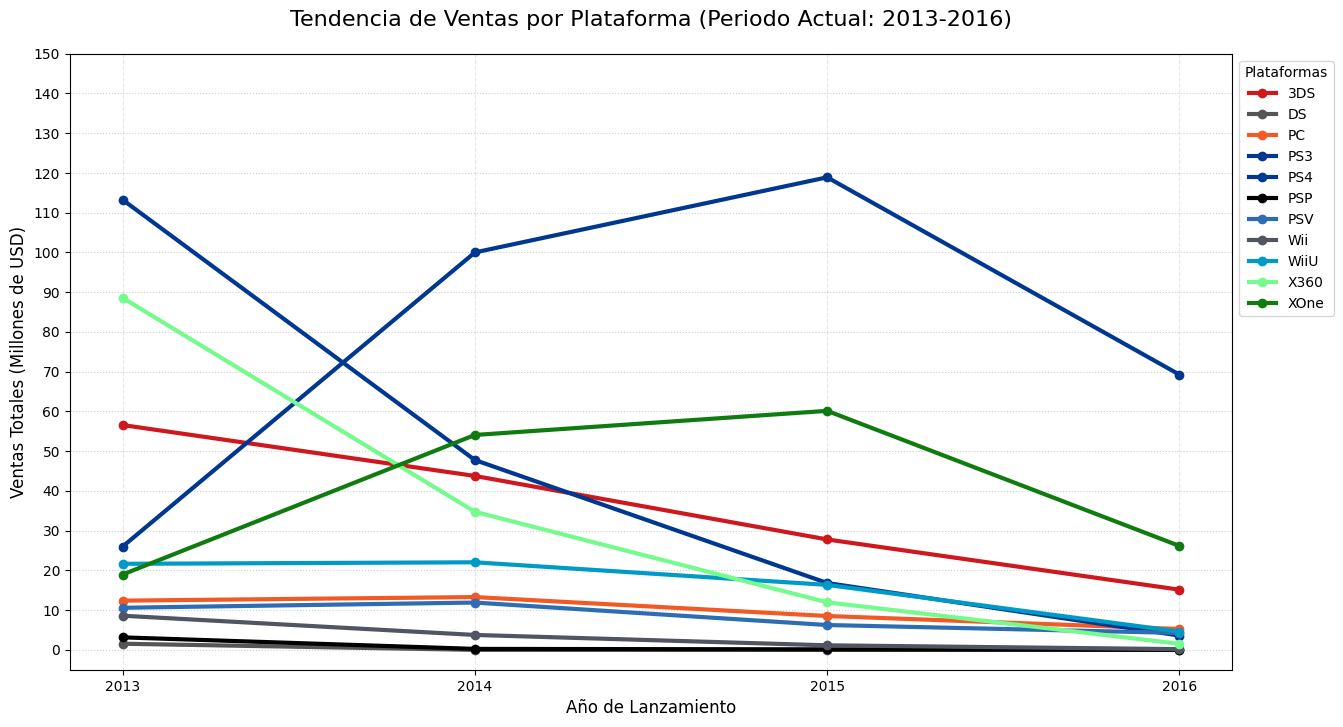

In [ ]:
pivot_actual = df_actual.pivot_table(index='year_of_release',
                                     columns='platform',
                                     values='total_sales',
                                     aggfunc='sum').fillna(0)
colores_dict = {
    'PS4': '#003791',
    'XOne': '#107C10',
    '3DS': '#CE181E',
    'PS3': '#003791',
    'X360': '#75FA8D',
    'WiiU': '#009AC7',
    'PC': '#F15A24',
    'PSV': '#2E6DB4',
    'Wii': '#515461',
    'DS': '#555555',
    'PSP': '#000000'
}

colores_ordenados = [colores_dict.get(col, '#808080') for col in pivot_actual.columns]

plt.figure(figsize=(15, 8))

ax = pivot_actual.plot(
    kind='line',
    figsize=(15, 8),
    marker='o',
    linewidth=3,
    color=colores_ordenados
)

plt.title('Tendencia de Ventas por Plataforma (Periodo Actual: 2013-2016)', fontsize=16, pad=20)
plt.xlabel('Año de Lanzamiento', fontsize=12)
plt.ylabel('Ventas Totales (Millones de USD)', fontsize=12)
plt.xticks([2013, 2014, 2015, 2016])
plt.grid(axis='both', linestyle='--', alpha=0.3)
plt.legend(title='Plataformas', bbox_to_anchor=(1.0, 1.0), loc='upper left', fontsize=10)
plt.ylim(-5, 150)
plt.yticks(np.arange(0, 151, 10))
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.show()

Tras generar el gráfico, observamos los resultados contenidos en el dataframe de ventas actuales (actual_platform_sales). El top 5 de plataformas está conformado por: 1.º PS4, 2.º PS3, 3.º XONE, 4.º X360 y 5.º WiiU.

- Plataformas en declive: Tanto PS3, X360 como WiiU muestran una tendencia descendente pronunciada, lo que indica que se encuentran en la etapa final de su ciclo de vida; por tanto, serán excluidas de los análisis posteriores.

- Líderes de mercado: Las plataformas con mayor volumen de ventas en el periodo 2013-2016 son PS4 y XONE. Por su parte, la 3DS de Nintendo mantiene una presencia relevante; aunque su tendencia indica que se acerca al final de su ciclo, las consolas portátiles suelen presentar una mayor longevidad. Por estas razones, centraremos nuestra atención en PS4, XONE y 3DS.

- Análisis de la plataforma PC: El resto de las plataformas presenta una tendencia a la baja. Un caso particular es la PC, que muestra ventas constantes pero moderadas. Esto podría atribuirse a factores como la piratería o el predominio del formato digital, que a menudo no se refleja totalmente en los conteos de ventas físicas. A diferencia de las consolas, la PC no tiene un ciclo de vida definido, ya que su ecosistema se actualiza constantemente a través de sus componentes.

In [ ]:
platform_list = ['PS4', 'XOne', '3DS']
df_top_interest = df_actual[df_actual['platform'].isin(platform_list)].copy()
print(df_top_interest['platform'].unique())

['PS4' '3DS' 'XOne']


/tmp/ipykernel_381/2136467474.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_interest, x='platform', y='total_sales', order=platform_list, palette=colores_especificos)


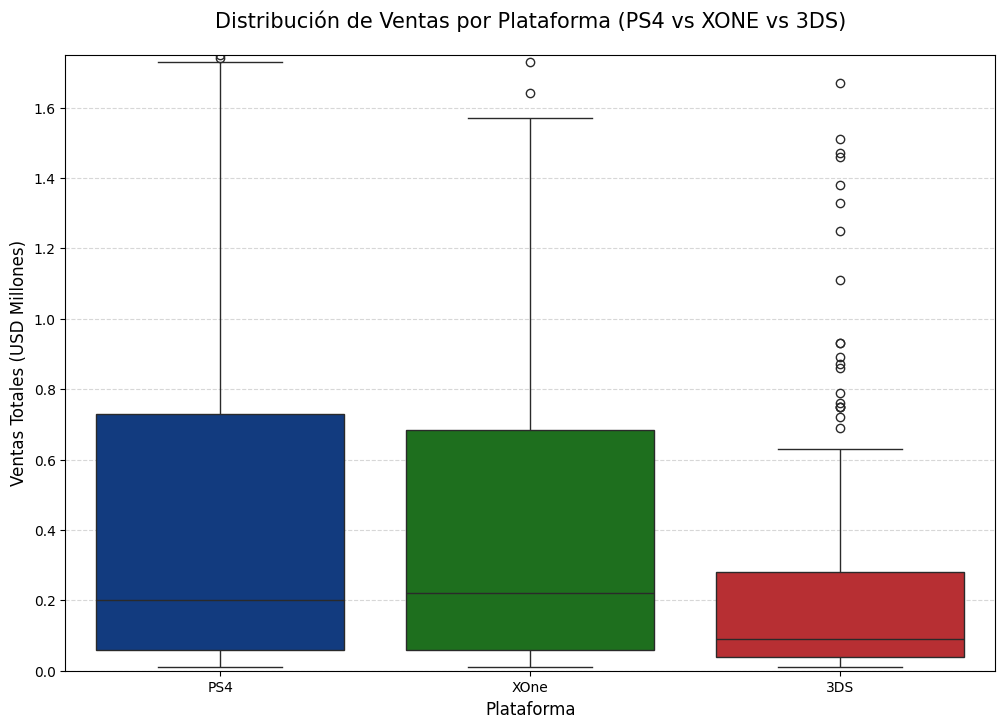

In [ ]:
colores_especificos = {
    'XOne': '#107C10',
    '3DS': '#CE181E',
    'PS4': '#003791'
}

plt.figure(figsize=(12, 8))

sns.boxplot(data=df_top_interest, x='platform', y='total_sales', order=platform_list, palette=colores_especificos)

plt.ylim(0, 1.75)

plt.title('Distribución de Ventas por Plataforma (PS4 vs XONE vs 3DS)', fontsize=15, pad=20)
plt.xlabel('Plataforma', fontsize=12)
plt.ylabel('Ventas Totales (USD Millones)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Al analizar la distribución de las ventas, observamos que las medianas de PS4 y XOne son muy similares, lo que indica un rendimiento de mercado equiparable por título lanzado. No obstante, la PS4 presenta una mayor dispersión, sugiriendo un catálogo más amplio y diversificado.

Por el contrario, el rendimiento de la 3DS depende estrechamente de sus éxitos individuales (outliers); su mediana significativamente menor confirma que es una plataforma con un enfoque más de nicho en comparación con las consolas de sobremesa. Es importante notar que estos outliers inflan considerablemente las ventas totales, por lo que la mediana resulta ser una métrica más representativa que el promedio para entender el desempeño típico de esta plataforma.

In [ ]:
# 1. Filtramos solo PS4
df_ps4 = df_actual[df_actual['platform'] == 'PS4'].copy()

# 2. Convertimos user_score a numérico
df_ps4['user_score'] = pd.to_numeric(df_ps4['user_score'], errors='coerce')

# 3. Creamos un DataFrame sin nulos para el análisis de reseñas
df_ps4_reviews = df_ps4.dropna(subset=['critic_score', 'user_score'])

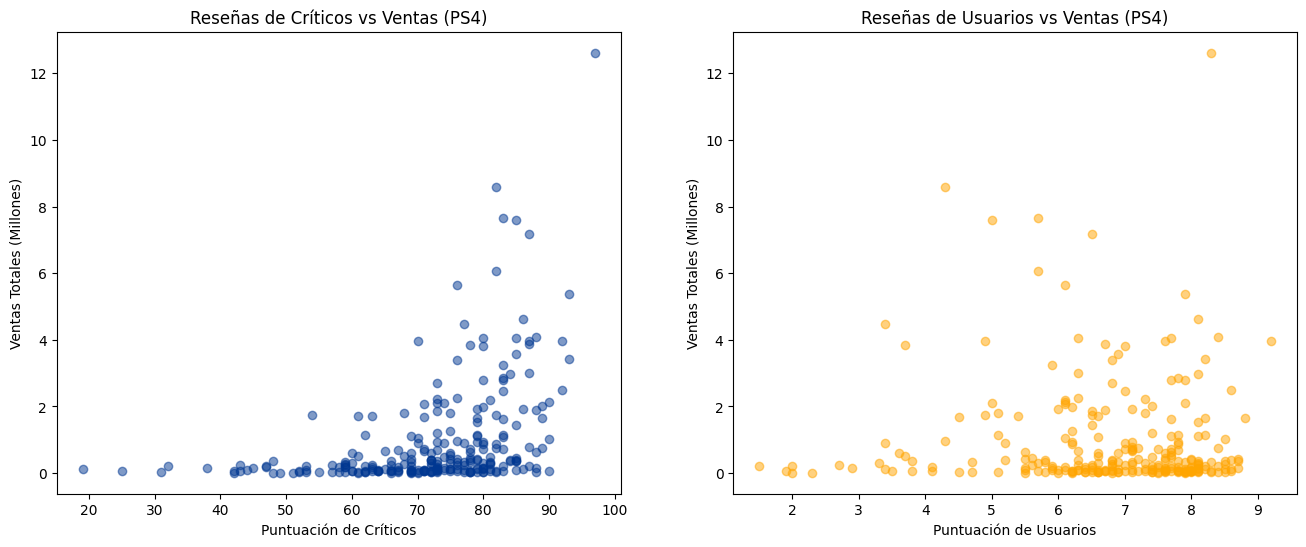

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Críticos vs Ventas
ax1.scatter(df_ps4_reviews['critic_score'], df_ps4_reviews['total_sales'], alpha=0.5, color='#003791')
ax1.set_title('Reseñas de Críticos vs Ventas (PS4)')
ax1.set_xlabel('Puntuación de Críticos')
ax1.set_ylabel('Ventas Totales (Millones)')

# Gráfico 2: Usuarios vs Ventas
ax2.scatter(df_ps4_reviews['user_score'], df_ps4_reviews['total_sales'], alpha=0.5, color='orange')
ax2.set_title('Reseñas de Usuarios vs Ventas (PS4)')
ax2.set_xlabel('Puntuación de Usuarios')
ax2.set_ylabel('Ventas Totales (Millones)')

plt.show()

In [ ]:
print("Correlación Críticos - Ventas:", df_ps4_reviews['critic_score'].corr(df_ps4_reviews['total_sales']))
print("Correlación Usuarios - Ventas:", df_ps4_reviews['user_score'].corr(df_ps4_reviews['total_sales']))

Correlación Críticos - Ventas: 0.40589480145836687
Correlación Usuarios - Ventas: -0.03362497596528878


Al analizar la plataforma PS4, concluimos que las reseñas de los críticos presentan una correlación moderada con las ventas globales: los títulos con mayores ingresos tienden a ostentar puntuaciones elevadas. Por el contrario, las reseñas de los usuarios no muestran una relación directa con el éxito comercial de un título, lo que sugiere que el comportamiento del consumidor masivo está impulsado por factores externos —como estrategias de marketing agresivas o la lealtad de marca—, más que por la calificación otorgada por la comunidad.

### 3. Comparación Ventas Titulos PS4 vs XOne

In [ ]:
games_platform_count = df_actual.groupby('name')['platform'].nunique()
multi_platform_games = games_platform_count[games_platform_count > 1].index

df_ps4_vs_xone_games = df_actual[df_actual['name'].isin(multi_platform_games)]

popular_platforms = ['PS4','XOne']

ps4_vs_xone_games_sales = df_actual[
    (df_actual['name'].isin(multi_platform_games)) &
    (df_actual['platform'].isin(popular_platforms))]

display(ps4_vs_xone_games_sales. head(10))


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,Unknown,14.63
42,Grand Theft Auto V,PS4,2014,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,12.62
77,FIFA 16,PS4,2015,Sports,1.12,6.12,0.06,1.28,82.0,4.3,E,8.58
87,Star Wars Battlefront (2015),PS4,2015,Shooter,2.99,3.49,0.22,1.28,NaN,NaN,Unknown,7.98
92,Call of Duty: Advanced Warfare,PS4,2014,Shooter,2.81,3.48,0.14,1.23,83.0,5.7,M,7.66
94,FIFA 17,PS4,2016,Sports,0.66,5.75,0.08,1.11,85.0,5.0,E,7.60
99,Call of Duty: Black Ops 3,XOne,2015,Shooter,4.59,2.11,0.01,0.68,NaN,NaN,Unknown,7.39
105,Fallout 4,PS4,2015,Role-Playing,2.53,3.27,0.24,1.13,87.0,6.5,M,7.17
143,FIFA 15,PS4,2014,Sports,0.80,4.33,0.05,0.90,82.0,5.7,E,6.08
154,Destiny,PS4,2014,Shooter,2.49,2.07,0.16,0.92,76.0,6.1,T,5.64


Filtramos el dataset para aislar únicamente los registros correspondientes a las plataformas Xbox One y PS4, con el objetivo de comparar directamente su rendimiento de mercado. Este subconjunto nos permitirá identificar los títulos multiplataforma —aquellos presentes en ambas consolas— y, mediante el filtrado de sus ventas, determinar cuáles han tenido un mayor éxito comercial para efectuar una comparación efectiva.

In [ ]:
df_pivot = ps4_vs_xone_games_sales.pivot_table(index='name', columns='platform', values='total_sales')

df_both = df_pivot.dropna()

df_top_10 = df_both.sort_values(by='PS4', ascending=False).head(10)

display(df_top_10)

platform,PS4,XOne
name,,
Call of Duty: Black Ops 3,14.63,7.39
Grand Theft Auto V,12.62,5.47
FIFA 16,8.58,3.25
Star Wars Battlefront (2015),7.98,3.66
Call of Duty: Advanced Warfare,7.66,5.26
FIFA 17,7.60,2.65
Fallout 4,7.17,4.22
FIFA 15,6.08,2.18
Destiny,5.64,3.37


Generamos una tabla dinámica con los diez títulos multiplataforma de mayor éxito comercial. Esta estructura nos permitirá consolidar la información necesaria para crear un gráfico de barras comparativo, el cual ilustrará claramente el volumen de ventas generado por cada consola para estos títulos específicos.

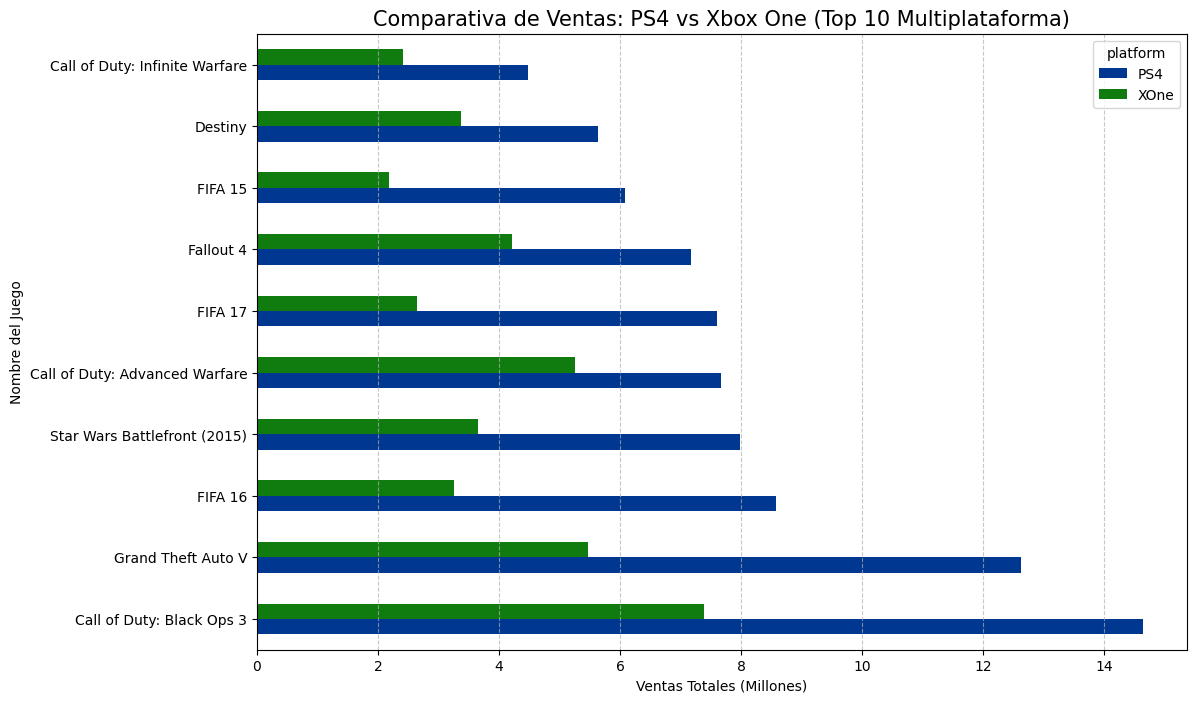

In [ ]:
df_top_10.plot(kind='barh', figsize=(12, 8), color=['#003791', '#107C10'])

plt.title('Comparativa de Ventas: PS4 vs Xbox One (Top 10 Multiplataforma)', fontsize=15)
plt.xlabel('Ventas Totales (Millones)')
plt.ylabel('Nombre del Juego')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

Se observa que PlayStation domina las ventas en todos los títulos de la lista; en algunos casos, supera por más del doble a Xbox. Esto sugiere una base de usuarios significativamente mayor, lo cual es consistente con nuestros análisis previos y refuerza la estrategia de priorizar la plataforma PS4. Además, el gráfico revela que el género shooter es particularmente atractivo, con el título Call of Duty: Black Ops 3 superando los 14 millones de unidades vendidas.

In [ ]:
df_genre = df_actual.groupby('genre')['total_sales'].agg(['sum','median']).sort_values(by='sum',ascending=False)

display(df_genre)

top_genres = df_genre.head()

display(top_genres)


,sum,median
genre,,
Action,321.87,0.110
Shooter,232.98,0.450
Sports,150.65,0.240
Role-Playing,145.89,0.125
Misc,62.82,0.100
Platform,42.63,0.225
Racing,39.89,0.120
Fighting,35.31,0.125
Adventure,23.64,0.030


,sum,median
genre,,
Action,321.87,0.110
Shooter,232.98,0.450
Sports,150.65,0.240
Role-Playing,145.89,0.125
Misc,62.82,0.100


Creamos un filtro para agrupar los datos por género, utilizando este como índice y calculando tanto la suma como la mediana de las ventas totales. Este procedimiento nos permitirá identificar qué géneros son los más rentables y evaluar la eficiencia de cada uno, contrastando estos resultados con los patrones observados previamente en nuestro análisis.

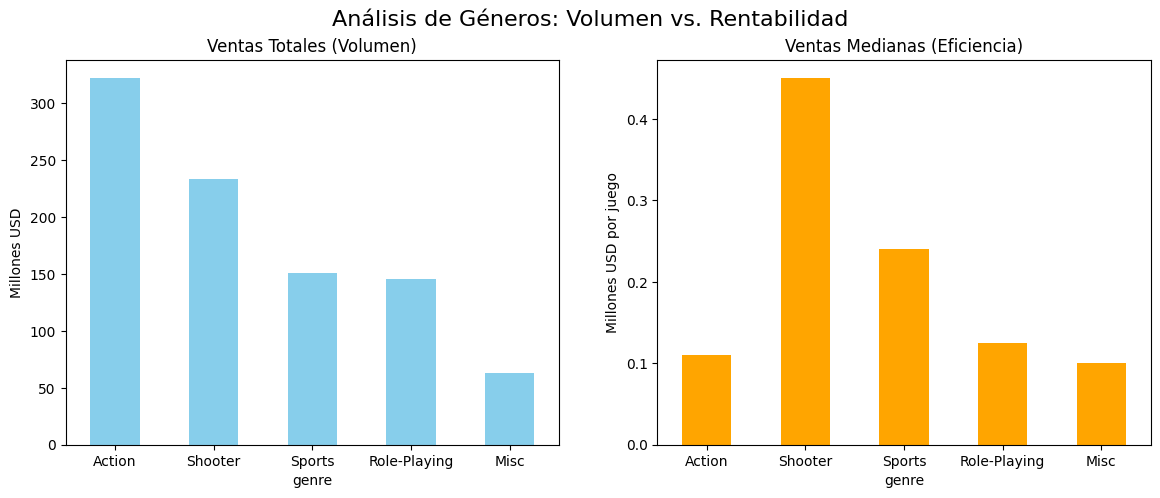

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_genres['sum'].plot(kind='bar', ax=axes[0], color='skyblue', title='Ventas Totales (Volumen)',rot=0,)
axes[0].set_ylabel('Millones USD')

top_genres['median'].plot(kind='bar', ax=axes[1], color='orange', title='Ventas Medianas (Eficiencia)',rot=0)
axes[1].set_ylabel('Millones USD por juego')

plt.suptitle('Análisis de Géneros: Volumen vs. Rentabilidad', fontsize=16)

plt.show()



Tras el análisis comparativo, las siguientes observaciones son clave:

- Género de Acción (Volumen): Representa el segmento con mayores ventas totales, consolidándose como un mercado indispensable para maximizar el alcance de nuestra estrategia.

- Género Shooter (Eficiencia): Presenta las medianas de ventas más elevadas, lo que indica que, en promedio, los títulos de este género ofrecen un rendimiento más consistente y rentable. Por tanto, representan la opción más segura para nuestra estrategia comercial.

# 4. Perfiles Por Region

### 4.1 Determinaremos por region las principales plataformas y compararemos sus cuotas entre si.

In [ ]:
# Norteamérica
na_platforms = df_actual.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head(5)
na_market_share = na_platforms / df_actual['na_sales'].sum()

print("% Top 5 Plataformas en NA:")
display(na_market_share*100)


print('=='*50)
# Europa
eu_platforms = df_actual.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).head(5)
eu_market_share = eu_platforms / df_actual['eu_sales'].sum()

print("% Top 5 Plataformas en EU:")
display(eu_market_share*100)

print('=='*50)
# Japon
jp_platforms = df_actual.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).head(5)
jp_market_share = jp_platforms / df_actual['jp_sales'].sum()

print(" % Top 5 Plataformas en JP:")
display(jp_market_share*100)



% Top 5 Plataformas en NA:


,na_sales
platform,
PS4,24.842933
XOne,21.274360
X360,18.656188
PS3,14.507322
3DS,8.727239


% Top 5 Plataformas en EU:


,eu_sales
platform,
PS4,35.971241
PS3,17.288326
XOne,13.152997
X360,10.840578
3DS,7.893328


 % Top 5 Plataformas en JP:


,jp_sales
platform,
3DS,48.167353
PS3,16.586163
PSV,13.205001
PS4,11.336838
WiiU,7.728371


**Observaciones:**

- El duelo de los gigantes en norteamerica entre PS4 y Xbox One es claro aqui, entre ambas consolas pero con PS4 a la cabeza coincide con nuestros analisis anteriores, el mercado objetivo de la estrategia para 2017 es con PS4 principalmente, aunque tambien con Xbox One no hay que ceder. Estos dos acaparan un 46 % del mercado, 24.84 % para PS4 y 21.27 % para Xbox One asi que una estrategia para ambos es viable en norteamerica priorizando PS4.

- En Europa tambien domina PS4, seguido de su antecesor el PS3 aunque este al estar en su ciclo de salida una estrategia no es viable. los esfuerzos deben concentrarce plenamente en PS4 ya que poor si solo acapara un 34 % del mercado regiona.

- En Japon las cosas cambian, casi el 50% del mercado es dominado por el 3DS de Nintendo, marca su precencia local muy fuertemente, auunque no se adapta a la estrategia global no es un mercado que se deba descuidar. una campaña regiona para 3Ds podria prolongar aun mas la lcola de vida de la consola. Tambien se observa que Playstation esta presente en conjunto, no individualmente estan presentes las 3 consolas existentes en ese momento acaparando un 41% del mercado repartido entre las 3, asai que tampoco se deberia descartarse de la estrategia global para Playstation. aunque el foco del marketing dependera del genero preferido por region que veremos a continuación.



### 4.2 Plataformas Principales por Region.

En esta sección, evaluaremos la cuota de mercado que ostentan las cinco consolas con mayor volumen de ventas por región. Este análisis nos permitirá identificar patrones de consumo específicos de los usuarios según su ubicación geográfica.

In [ ]:
na_genres = df_actual.groupby('genre')['na_sales'].sum().sort_values(ascending=False).head(5)
na_genre_share = na_genres / df_actual['na_sales'].sum()

print("Top 5 Generos en NA:")
display(na_genre_share)
print('=='*50)

eu_genres = df_actual.groupby('genre')['eu_sales'].sum().sort_values(ascending=False).head(5)
eu_genre_share = eu_genres / df_actual['eu_sales'].sum()

print("Top 5 Generos en EU:")
display(eu_genre_share)
print('=='*50)

jp_genres = df_actual.groupby('genre')['jp_sales'].sum().sort_values(ascending=False).head(5)
jp_genre_share = jp_genres / df_actual['jp_sales'].sum()

print("Top 5 Generos en EU:")
display(jp_genre_share)



Top 5 Generos en NA:


,na_sales
genre,
Action,0.287976
Shooter,0.250714
Sports,0.149117
Role-Playing,0.106006
Misc,0.062804


Top 5 Generos en EU:


,eu_sales
genre,
Action,0.301175
Shooter,0.224001
Sports,0.154297
Role-Playing,0.094256
Racing,0.051475


Top 5 Generos en EU:


,jp_sales
genre,
Role-Playing,0.362551
Action,0.287612
Misc,0.065350
Fighting,0.054340
Shooter,0.046953


**Observaciones:**

- Los Generos de accion y Shooters Tanto en ANorteamerica y Europa se reparten el 50 % seguidos de Sports, estos 3 generos deben ser clave y usar titulos de alta demanda como los son GTA V Call of Duty , y FIFA para la atraccion de compradores estos juegos ofrecidos en bundles con la consola son el gancho perfecto para la estrategia en conjunto a la plataforma por region.

- En Japon los Gustos son diferentes y la cultura, notamos que los RPG son los mas demandados, dominando con un 36% de las ventas. seguido de el genero accion con un porcentaje de 28%, estos 2 generos seran claves para la estrategia.

### 4.3 Generos principales de consumo.

Aplicaremos la misma metodología empleada anteriormente, esta vez enfocada en los géneros, con el fin de detectar patrones de consumo vinculados a las distintas consolas. Este análisis nos permitirá determinar con precisión el enfoque estratégico que debemos adoptar de cara al año 2017.

In [ ]:
na_rating = df_actual.groupby('rating')['na_sales'].sum().sort_values(ascending=False).head(5)
na_rating_share = na_rating / df_actual['na_sales'].sum()

print("% Top 5 Clasificaciones en NA:")
display(na_rating_share*100)
print('=='*50)

eu_rating = df_actual.groupby('rating')['eu_sales'].sum().sort_values(ascending=False).head(5)
eu_rating_share = eu_rating / df_actual['eu_sales'].sum()

print("% Top 5 Clasificaciones en EU:")
display(eu_rating_share*100)
print('=='*50)

jp_rating = df_actual.groupby('rating')['jp_sales'].sum().sort_values(ascending=False).head(5)
jp_rating_share = jp_rating / df_actual['jp_sales'].sum()

print("% Top 5 Clasificaciones en EU:")
display(jp_rating_share*100)


% Top 5 Clasificaciones en NA:


,na_sales
rating,
M,37.744169
Unknown,20.429051
E,18.059903
E10+,12.391766
T,11.375111


% Top 5 Clasificaciones en EU:


,eu_sales
rating,
M,37.049690
E,21.252836
Unknown,20.118298
E10+,10.883920
T,10.695255


% Top 5 Clasificaciones en EU:


,jp_sales
rating,
Unknown,60.413411
T,14.625657
E,10.754369
M,10.022731
E10+,4.183833


**Observaciones**

- La Clasificacion "M" de Mature, es la predominante en la region de Norteamerica con 37 % los usuarios tienen gusto por los juegos explicitos y con contenido para mayores, como es de esperarse dado el alto indice de juegos Shooter con contenido explicito, y los juegos de accion. por lo que la campaña en conjunto con los generos de accion y shooter es ideal en esta region para PS4 y Xbox. En segundo Lugar Tenemos los Juegos con la Clasificacion "Unknown" que creamos anteriormente, esto puede ser a que sean juegos extranjeros y no se rigan explicitamente por las normas de clasificación de nborteamerica. es interesante este dato. como tercer lugar con un 18%, tenemos a los juegos que pueden ser para cualquer edad lo cual tambien es un mercado interesante ya que siempre es un mercadoen crecimiento mas con las nuevas generaciones que entran dirtecto al mundo digital.

- Se repite el patron que notamos en norteamerica pero intercambiando lugares la clasificación "Unknow" por "Everyone" lo que indica que el segundo puesto es mas un mercado familiar. la estrategia principal sigue siendo viable.

- En Japon si que tenemos gustos muy diferentespero esto es por que muchos de los juegos que se lanzan en japon no llegan a norteamerica, y tienen sus propios esquemas para clasificar los juegos y que no entran dentro del mismo estandar que norteamerica, seguido po un publico mayormente adolecente y familiar. algo muy comun en los juegos de nintendo que tienen ese balance de ser familiares pero atractivos para cualquier edad.



---



# 5. Pueba de Hipotesis

Validaremos si las diferencias que vemos son estadísticamente significativas o solo pura casualidad o suerte.

probaremos 2 Hipótesis para este paso:

 ### 5.1 Hipótesis 1: Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.

  **Las preguntas principales:**
  
  Xbox One y PC comparten muchos juegos. ¿Sera que los usuarios de ambas plataformas califican igual los juegos, o los usuarios de PC son más exigentes con sus notas?
  
   **a.** Hipótesis Nula ($H_0$): Las medias son iguales (Xbox One = PC).

  **b.** Hipótesis Alternativa ($H_1$): Las medias son diferentes.

  - Para este paso comezaremos agrupando los datos de nuestro dataframe filtrado llamado "df_actual" el cual contiene las consolas que necesitamos comparar y que nos interesan para la estrategia.
  - Usaremos la Prueba T test para comparar 2 pruebas independientes dependiendo de los datos de la media y la varianza que obtengamos determinaremos si es necesario estableceer una prueba de varianzas similares o de varianzas desiguales.
  - Estableceremos el Valor aplha en un 0.05% como estandar a menos que los datos obtenidos nos hagn cambiar de opinion.

In [ ]:
# 1. Filtramos el Dataset "df_actual" por plataforma con la condicional de encontrar solo "XOne" extraemos la columna "user_Score" y aplicamos el metodo "dropna" para eliminas esos valores nulos que teniamos en esta columna ya eue no serian procesdos por la prueba.

xone_ratings = df_actual[df_actual['platform'] == 'XOne']['user_score'].dropna()

# 2. Aplicamos el Mismo metodo para filtrar las calificacionesen "PC".

pc_ratings = df_actual[df_actual['platform'] == 'PC']['user_score'].dropna()

# 3. Con los Dataframes Filtrados sacamos los valores que correspondrian al "Promedio" , "Desviacion estandar" y la " Varianza".
xone_ratings_mean = xone_ratings.mean()
xone_ratings_std = xone_ratings.std()
xone_ratings_var = xone_ratings.var()
pc_ratings_mean = pc_ratings.mean()
pc_ratings_std = pc_ratings.std()
pc_ratings_var = pc_ratings.var()

# 4. Imprimimos los resultados.

print(f"El promedio de las calificaciones de Xbox One es: {xone_ratings_mean:.2F}, y la Varianza tiene un valor de: {xone_ratings_var:.2f} ")
print()
print(f"El promedio de las calificaciones en PC es: {pc_ratings_mean:.2F}, y la Varianza tiene un valor de: {pc_ratings_var:.2f} ")
print()
print(f"Desviación estándar Xbox One: {xone_ratings_std:.2f}, Desviación estándar PC: {pc_ratings_std:.2f}")



El promedio de las calificaciones de Xbox One es: 6.52, y la Varianza tiene un valor de: 1.91 

El promedio de las calificaciones en PC es: 6.27, y la Varianza tiene un valor de: 3.04 

Desviación estándar Xbox One: 1.38, Desviación estándar PC: 1.74


**Observaciones**

Al comparar las calificaciones de los usuarios, observamos que las medias son bastante similares (6.52 para Xbox One frente a 6.27 para PC). Sin embargo, al analizar la dispersión de los datos, notamos diferencias interesantes:

- La desviación estándar en PC (1.74) es superior a la de Xbox One (1.38). Esto indica que, mientras que en Xbox los usuarios tienden a mantener una opinión más estable, en PC las calificaciones están más 'regadas' o dispersas.

- Esto sugiere que el público de PC presenta una mayor discusion en sus críticas, con una mayor cantidad de usuarios que expresan posturas extremas —ya sea de gran satisfacción o de rechazo— en comparación con el perfil de usuario de Xbox. En pocas palabras: "o los odian o los aman."

In [ ]:
# 1. Definimos nuestro nivel de significancia
alpha = 0.05

# 2. Ejecutamos la prueba
results = st.ttest_ind(xone_ratings, pc_ratings, equal_var=False)

print(f'p-value: {results.pvalue}')

# 3. Comparamos el p-value con alpha
if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula: las calificaciones son diferentes.")
else:
    print("No podemos rechazar la hipótesis nula: las calificaciones son similares.")

p-value: 0.14759594013430463
No podemos rechazar la hipótesis nula: las calificaciones son similares.


 ### 5.2 Hipótesis 2: Las calificaciones promedio de los usuarios para los géneros de Acción y Deporte son diferentes.

  **Las preguntas principales:**
  
  El genero de Accion y de Deportes Tienen mucha popularidad en todas las regiones. ¿Los usuarios de los juegos de Acción califican igual los juegos, o los usuarios de los juegos de Deportes son mas rigurosos con sus opiniones?.

  **a.** Hipótesis Nula ($H_0$): Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son iguales.

  **b.** Hipótesis Alternativa ($H_1$): Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.


  - Repetiremos la Agrupacion y la prueba t test para estas 2 muestras de igual forma dependiedno de los datos obtenidos a continuacion  sobre la varianza, desviacion estandar y la media, estableceremos siu usamos el parametro de pruebas similares o no.
  - Estableceremos el valor alpha para tener un margen estadar de acción.

In [ ]:
action_ratings = df_actual[df_actual['genre'] == 'Action']['user_score'].dropna()

sports_ratings = df_actual[df_actual['genre'] == 'Sports']['user_score'].dropna()

action_ratings_mean = action_ratings.mean()
action_ratings_std =action_ratings.std()
action_ratings_var = action_ratings.var()
sports_ratings_mean = sports_ratings.mean()
sports_ratings_std = sports_ratings.std()
sports_ratings_var = sports_ratings.var()


print(f"El promedio de las calificaciones del genero 'Action' es: {action_ratings_mean:.2F}, y la Varianza tiene un valor de: {action_ratings_var:.2f} ")
print()
print(f"El promedio de las calificaciones del genero 'Sports' es:: {sports_ratings_mean:.2F}, y la Varianza tiene un valor de: {sports_ratings_var:.2f} ")
print()
print(f"Desviación estándar Acción: {action_ratings_std:.2f}, Desviación estándar Deportes: {sports_ratings_std:.2f}")


El promedio de las calificaciones del genero 'Action' es: 6.84, y la Varianza tiene un valor de: 1.77 

El promedio de las calificaciones del genero 'Sports' es:: 5.24, y la Varianza tiene un valor de: 3.18 

Desviación estándar Acción: 1.33, Desviación estándar Deportes: 1.78


**Observaciones**

Al comparar el género de Acción frente al de Deportes, observamos una diferencia significativa en las valoraciones:

- El género de Acción mantiene una media superior de 6.84, mientras que Deportes se sitúa en 5.24. Esta brecha de 1.6 puntos no es casualidad; al analizar la dispersión, la desviación estándar en Deportes (1.78) es notablemente mayor a la del género de Acción (1.33). Esto confirma que, además de tener una calificación promedio más baja, las opiniones en el género de Deportes están mucho más dispersas.

- Dado que las varianzas y desviaciones son tan distintas entre ambos grupos, realizamos la prueba estadística utilizando el parámetro `equal_var=False (Prueba de Welch)`. El p-value obtenido de 1.44e-20 es extremadamente bajo, lo que nos permite rechazar con total seguridad la hipótesis nula: existe una diferencia real y estadísticamente significativa en cómo los usuarios califican estos dos géneros.

In [ ]:
results_genre = st.ttest_ind(action_ratings, sports_ratings, equal_var=False)

print(f'p-value: {results_genre.pvalue}')

if results_genre.pvalue < alpha:
    print("Rechazamos la hipótesis nula: las calificaciones son diferentes.")
else:
    print("No podemos rechazar la hipótesis nula: las calificaciones son similares.")

p-value: 1.4460039700704315e-20
Rechazamos la hipótesis nula: las calificaciones son diferentes.


**Observaciones**

- Existe una diferencia estadísticamente significativa entre las calificaciones de los usuarios para los juegos de Acción y los de Deportes.

- Normalmente los fans de los juegos de deportes suelen ser más "duros" con sus calificaciones debido a que son juegos que se lanzan año con año. Si el juego no cambia lo suficiente contra el pasado, los usuarios suelen castigarlo con notas bajas, lo que explicaria ese 5.24 frente al 6.84 de Acción.

# Conclusión General:

 Resultados del Plan de Acción

 Este proyecto fue desarrollado bajo una hoja de ruta de 5 puntos estratégicos. Al finalizar, estos son los resultados concretos obtenidos en cada etapa:

 1. Diagnóstico de la Estructura (Lectura y Análisis)Logramos una base de datos limpia y confiable. Al normalizar los nombres de las columnas a snake_case y corregir los formatos de las variables (de object a float/int), eliminamos el "ruido" de los datos. Esta etapa fue crítica: sin haber detectado los valores ausentes y los tipos de datos erróneos al inicio, el resto del análisis no habría tenido validez técnica.
    Métodos clave: .info(), .describe(), .shape, .isna().sum().

 2. Preparación y Orden (Limpieza de Datos)La creación de la columna Ventas Totales (la suma de todas las regiones) nos permitió tener una visión global del éxito de cada juego, más allá de lo que pasaba en un solo país. Al decidir cómo manejar los datos ausentes, garantizamos que el cálculo de las medias y desviaciones fuera preciso.

    - Métodos clave: .astype(), .fillna(), suma aritmética (df['sales'] = ...).

 3. Análisis de Tendencias (Buscando Historias)Detectamos que los lanzamientos de juegos han tenido ciclos marcados. Identificamos que la PS4 es la plataforma que sostiene el mercado actual, mientras que en Japón, la 3DS tiene una vigencia distinta. Entender estos ciclos nos permitió descartar plataformas obsoletas y enfocar nuestra atención en el mercado actual para 2017.

    - Métodos clave: .groupby(), .plot(kind='bar'), .pivot_table().

 4. Perfil Regional (¿Quién compra qué?)Confirmamos que la estrategia debe ser local, no global:Occidente: El mercado prefiere consolas de sobremesa y géneros de alta intensidad como Shooters y Acción.Japón: El mercado es de nicho, enfocado en portabilidad (3DS) y el género RPG.Calidad vs. Venta: Observamos que la crítica profesional es un filtro de calidad más estable para predecir ventas que la opinión del usuario.

    - Métodos clave: .groupby('region'), .nlargest(), .plot(kind='pie').

 5. Validación Científica (Pruebas de Hipótesis)Cerramos nuestro plan aplicando estadística para validar nuestras sospechas:Xbox One vs. PC: Con un $p\text{-value} = 0.147$, determinamos que los usuarios de ambos sistemas califican de forma similar. No hay diferencia real.Acción vs. Deportes: Con un $p\text{-value} = 1.44 \times 10^{-20}$, confirmamos una diferencia significativa. La alta desviación estándar en los juegos de Deportes (1.78) comparada con Acción (1.33) demuestra que los usuarios de deportes son mucho más exigentes y sus opiniones están más divididas, lo que añade riesgo a este género.

    - Métodos clave: .mean(), .var(), .std(), st.ttest_ind(equal_var=False).

 ## Resumen final


El plan de acción funcionó porque no dependimos de intuiciones. Al seguir estos 5 pasos, logramos diseñar una estrategia para 2017 basada en segmentación geográfica (PS4/Acción en Occidente, 3DS/RPG en Japón) y selección basada en crítica profesional, mitigando el riesgo que implica la alta variabilidad en las opiniones de los usuarios de deportes.